In [11]:
import xarray as xr
from pathlib import Path

In [12]:
output_file = Path("c:/Users/sjordan/Github/ClearWater-riverine/examples/data_temp/sumwere_creek_coarse_p48/model_outputs.zarr/")

In [13]:
ds = xr.open_zarr(output_file, consolidated=False)

In [14]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:            (time: 241, nface: 444)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2022-05-13T08:00:00 ... 2022...
  * nface              (nface) int64 4kB 0 1 2 3 4 5 ... 438 439 440 441 442 443
    face_y             (nface) float64 4kB dask.array<chunksize=(444,), meta=np.ndarray>
    face_x             (nface) float64 4kB dask.array<chunksize=(444,), meta=np.ndarray>
Data variables:
    water_temperature  (time, nface) float64 856kB dask.array<chunksize=(120, 1), meta=np.ndarray>
    tracer             (time, nface) float64 856kB dask.array<chunksize=(120, 1), meta=np.ndarray>

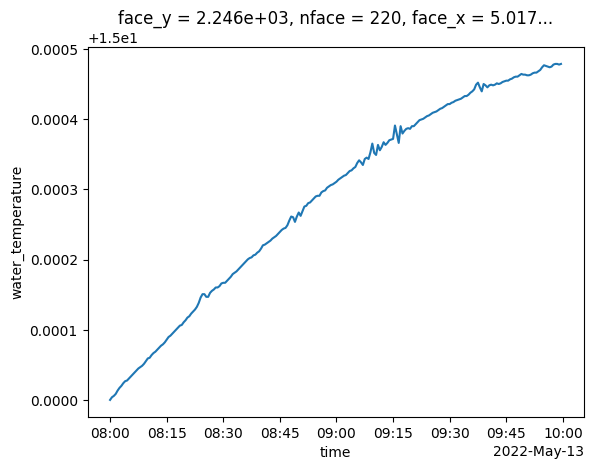

In [15]:
ds.water_temperature.isel(nface=220).plot()

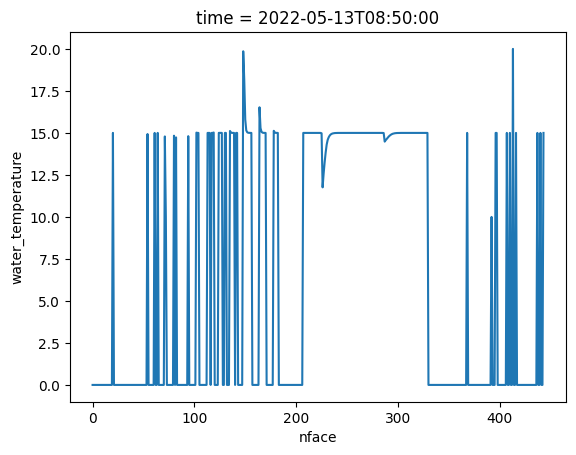

In [19]:
ds.water_temperature.isel(time=100).plot()

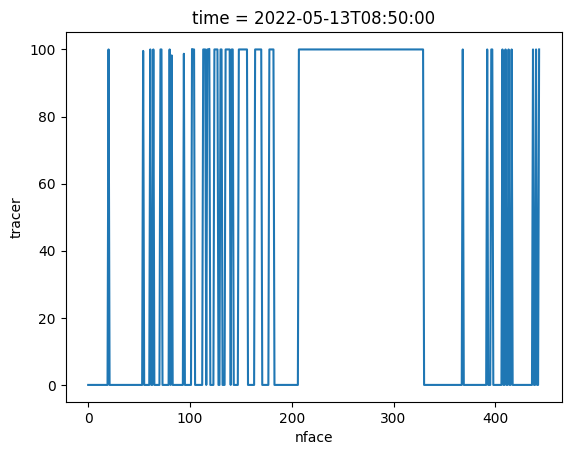

In [20]:
ds.tracer.isel(time=100).plot()

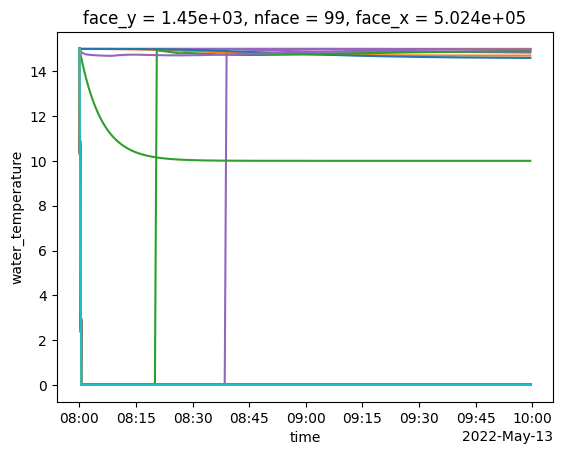

In [16]:
for n in range(10,100):
    ds.water_temperature.isel(nface=n).plot()

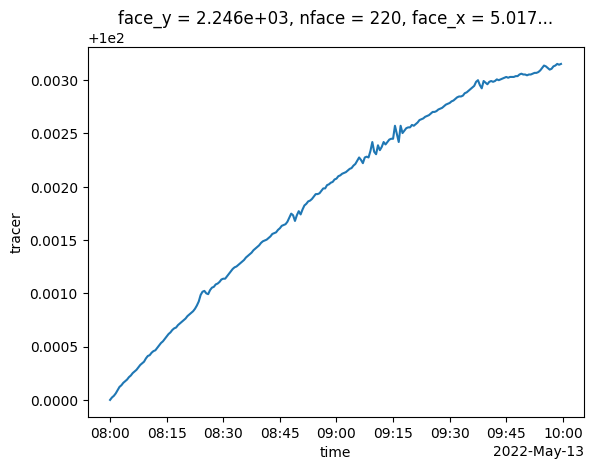

In [17]:
ds.tracer.isel(nface=220).plot()

In [18]:
ds.water_temperature.isel(nface=300, time=slice(110, 123)).values

array([1.49935770e+01, 1.49930811e+01, 1.49925566e+01, 1.49920044e+01,
       1.49914217e+01, 1.49908075e+01, 1.49901609e+01, 1.49894810e+01,
       1.49887667e+01, 1.49880142e+01,            nan, 3.24746585e-19,
       5.14067191e-18])

In [24]:
import clearwater_riverine as cwr
from pathlib import Path
import pandas as pd

# read config
working_dir = Path.cwd()
network_path = working_dir / 'examples/data_temp/sumwere_creek_coarse_p48'
config_file = network_path / 'example_config_refactor.yml'

# instantiate model
transport_model = cwr.ClearwaterRiverine(
    config_filepath=config_file,
)

transport_model.registry.get('water_temperature')
transport_model.registry.get('tracer')


transport_model.run()

ModuleNotFoundError: No module named 'geoviews'